In [195]:
!pip install mplfinance

In [196]:
!pip install yfinance

In [197]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf

In [198]:
data = yf.download('AAPL', start='2020-01-01', end='2026-07-24')

[*********************100%***********************]  1 of 1 completed


In [199]:
if isinstance(data, pd.DataFrame):
    print("Data is a DataFrame")

Data is a DataFrame


In [200]:
if isinstance(data.columns, pd.MultiIndex):
    print("Data is a DataFrame")
    data.columns = data.columns.droplevel(1)

Data is a DataFrame


In [201]:
data.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800
2020-01-13,76.334076,76.360571,74.934843,75.052856,121532000
2020-01-14,75.303337,76.481009,75.180518,76.271486,161954400


In [202]:
data.tail(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-07-10,315.320007,316.910004,312.170013,314.720001,34132300
2026-07-13,317.309998,323.450012,315.779999,317.019989,43257800
2026-07-14,314.859985,316.190002,311.910004,313.760010,36336800
2026-07-15,327.500000,328.730011,317.320007,317.619995,60957600
2026-07-16,333.260010,334.679993,326.790009,328.010010,62970600
2026-07-17,333.739990,334.989990,329.000000,331.980011,63407100
2026-07-20,326.589996,333.709991,323.679993,333.510010,53468000
2026-07-21,327.739990,329.600006,322.220001,323.130005,41338900
2026-07-22,325.890015,329.000000,323.339996,327.869995,38755900


In [203]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1647 non-null   float64
 1   High    1647 non-null   float64
 2   Low     1647 non-null   float64
 3   Open    1647 non-null   float64
 4   Volume  1647 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.2 KB


In [204]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [205]:
data.describe()


Price,Close,High,Low,Open,Volume
count,1647.000000,1647.000000,1647.000000,1647.000000,1.647000e+03
mean,174.227500,176.023192,172.267789,174.058002,8.165621e+07
std,57.443142,57.886305,56.955447,57.379693,5.051738e+07
min,54.163696,55.160694,51.324793,55.059305,1.791060e+07
25%,135.559044,137.916419,132.975647,134.940282,4.880845e+07
50%,168.504883,170.245709,167.143463,168.378201,6.725760e+07
75%,216.425232,218.462585,213.946476,215.900351,9.681695e+07
max,333.739990,334.989990,329.000000,333.510010,4.265100e+08


# Exploratory Data Analysis (EDA) on the stock data

## Visualization

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1400x800 with 0 Axes>

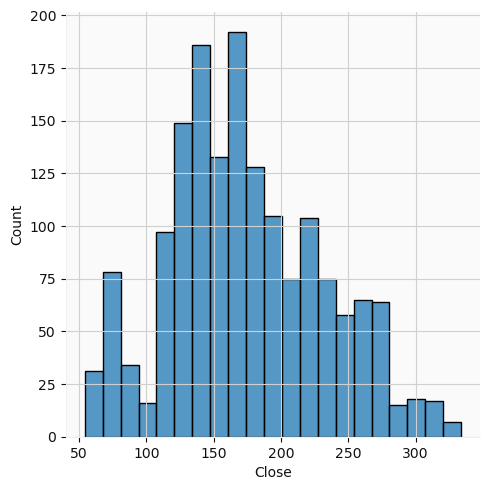

In [207]:
plt.figure(figsize=(14, 8))
sns.displot(data['Close'])
plt.show() 

<Figure size 1400x800 with 0 Axes>

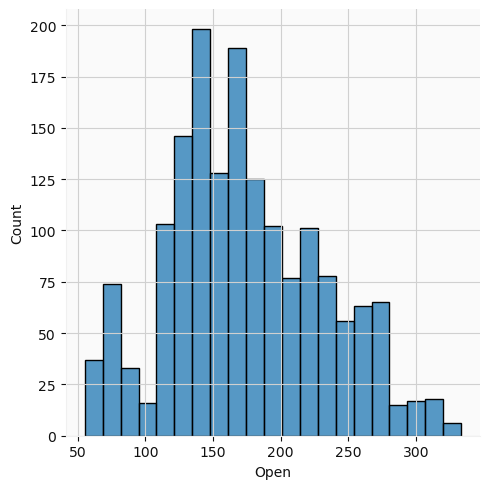

In [208]:
plt.figure(figsize=(14, 8))
sns.displot(data['Open'])
plt.show()

<Figure size 1400x800 with 0 Axes>

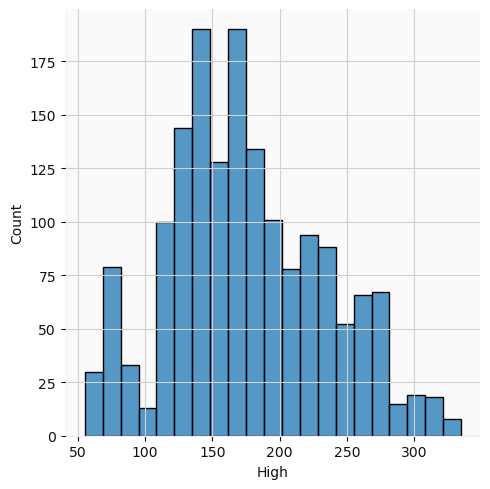

In [209]:
plt.figure(figsize=(14, 8))
sns.displot(data['High'])
plt.show()

<Figure size 1400x800 with 0 Axes>

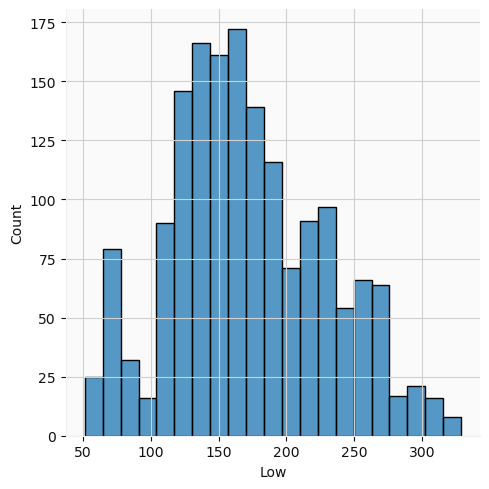

In [210]:
plt.figure(figsize=(14, 8))
sns.displot(data['Low'])
plt.show()

In [211]:
data.head()
type(data['Open'])

pandas.core.series.Series

In [212]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1647 non-null   float64
 1   High    1647 non-null   float64
 2   Low     1647 non-null   float64
 3   Open    1647 non-null   float64
 4   Volume  1647 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.2 KB


In [213]:
data['Open'] = data['Open'].astype(float)   

c:\Users\edgar\anaconda3\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


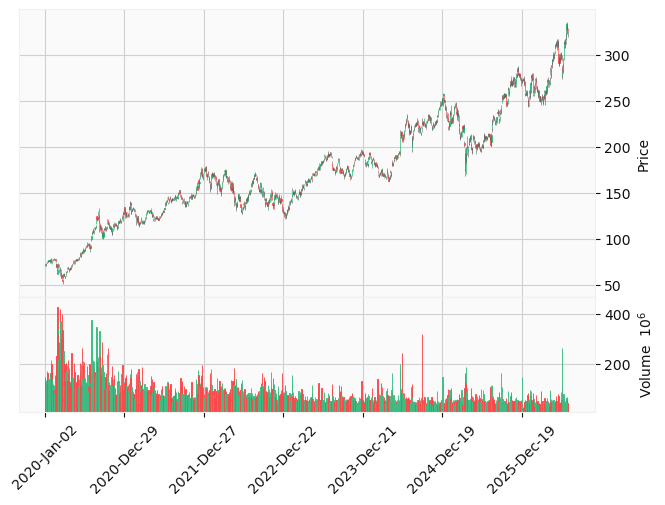

In [214]:
mpf.plot(
    data,
    type="candle",
    volume=True,
    style="yahoo"
)

Text(0.5, 1.0, 'Close Price with 20-Day Moving Average')

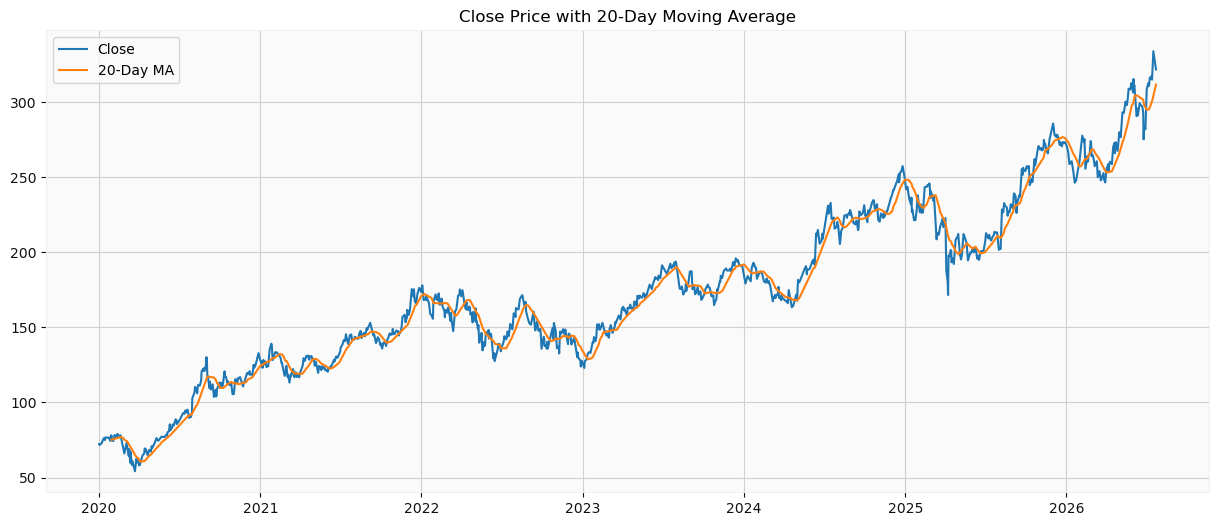

In [215]:
data["MA20"] = data["Close"].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA20"], label="20-Day MA")

plt.legend()
plt.title("Close Price with 20-Day Moving Average")

In [216]:
data['Close']

Date
2020-01-02     72.333855
2020-01-03     71.630646
2020-01-06     72.201439
2020-01-07     71.861855
2020-01-08     73.017853
                 ...    
2026-07-17    333.739990
2026-07-20    326.589996
2026-07-21    327.739990
2026-07-22    325.890015
2026-07-23    321.660004
Name: Close, Length: 1647, dtype: float64

In [217]:
# finish visuals

In [218]:
#6 Volume

In [219]:
data["Volume_MA20"] = (
    data["Volume"]
    .rolling(20)
    .mean()
)

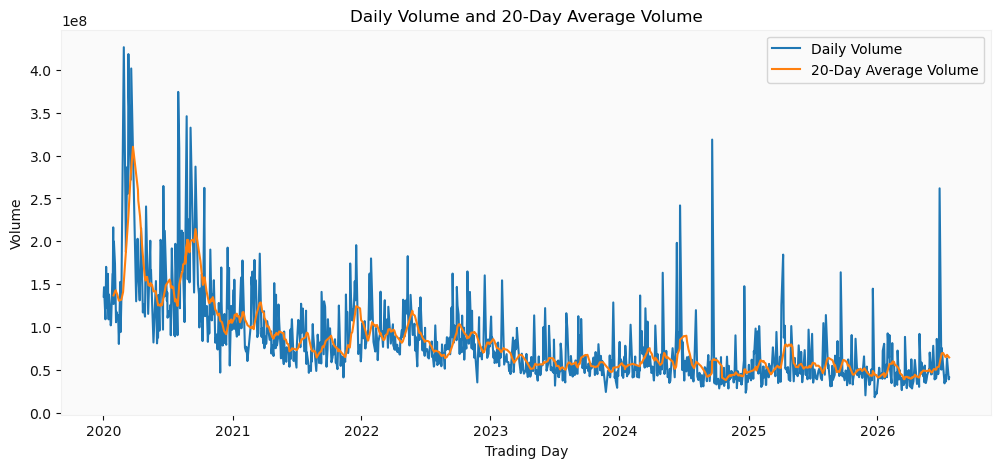

In [220]:
plt.figure(figsize=(12, 5))

plt.plot(data["Volume"], label="Daily Volume")
plt.plot(data["Volume_MA20"], label="20-Day Average Volume")

plt.title("Daily Volume and 20-Day Average Volume")
plt.xlabel("Trading Day")
plt.ylabel("Volume")
plt.legend()
plt.grid()

plt.show()

In [221]:
#Volume Change

In [222]:
data["Volume_Change"] = (
    data["Volume"]
    .pct_change()
)

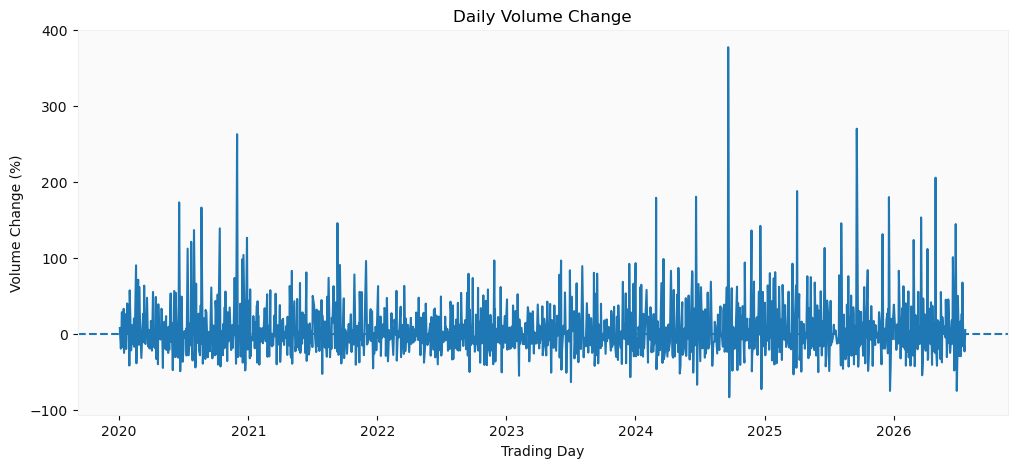

In [223]:
plt.figure(figsize=(12, 5))
plt.plot(data["Volume_Change"] * 100)
plt.axhline(y=0, linestyle="--")
plt.title("Daily Volume Change")
plt.xlabel("Trading Day")
plt.ylabel("Volume Change (%)")
plt.grid()

plt.show()

* We can see a high volume change during September 2020 - January 2021

In [224]:
#Relative volume

In [225]:
data["Relative_Volume"] = (
    data["Volume"] /
    data["Volume_MA20"]
)

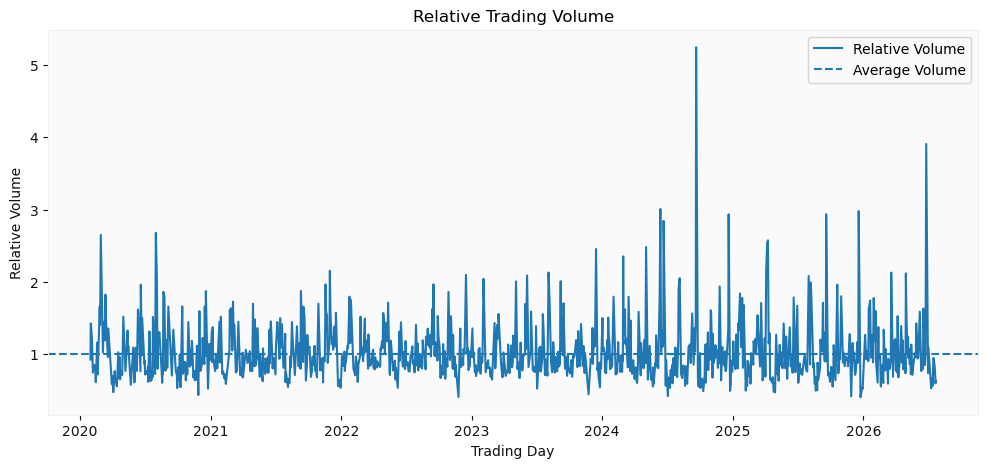

In [226]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Relative_Volume"],
    label="Relative Volume"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Average Volume"
)

plt.title("Relative Trading Volume")
plt.xlabel("Trading Day")
plt.ylabel("Relative Volume")
plt.legend()
plt.grid()

plt.show()

In [227]:
# 7

In [228]:
#Daily. Range

In [229]:
data["Daily_Range"] = (
    data["High"] -
    data["Low"]
)

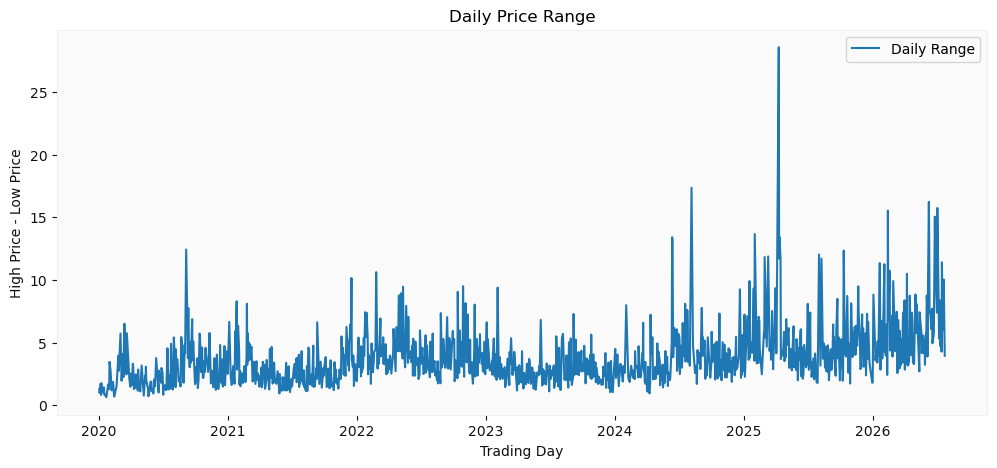

In [230]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Daily_Range"],
    label="Daily Range"
)

plt.title("Daily Price Range")
plt.xlabel("Trading Day")
plt.ylabel("High Price - Low Price")
plt.legend()
plt.grid()

plt.show()

In [231]:
#Close vs open

In [232]:
data["Close_Open_Diff"] = (
    data["Close"] -
    data["Open"]
)

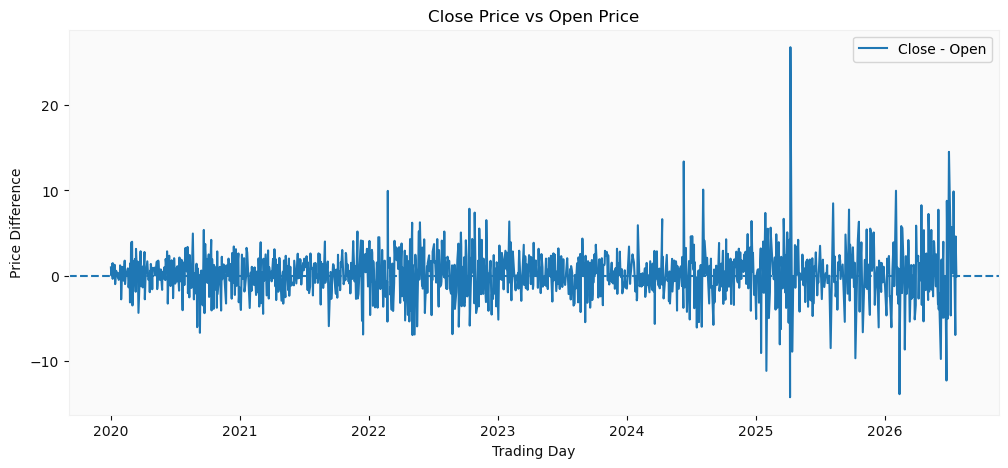

In [233]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["Close_Open_Diff"],
    label="Close - Open"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Close Price vs Open Price")
plt.xlabel("Trading Day")
plt.ylabel("Price Difference")
plt.legend()
plt.grid()

plt.show()

In [234]:
#High vs Close

In [235]:
data["High_Close_Diff"] = (
    data["High"] -
    data["Close"]
)

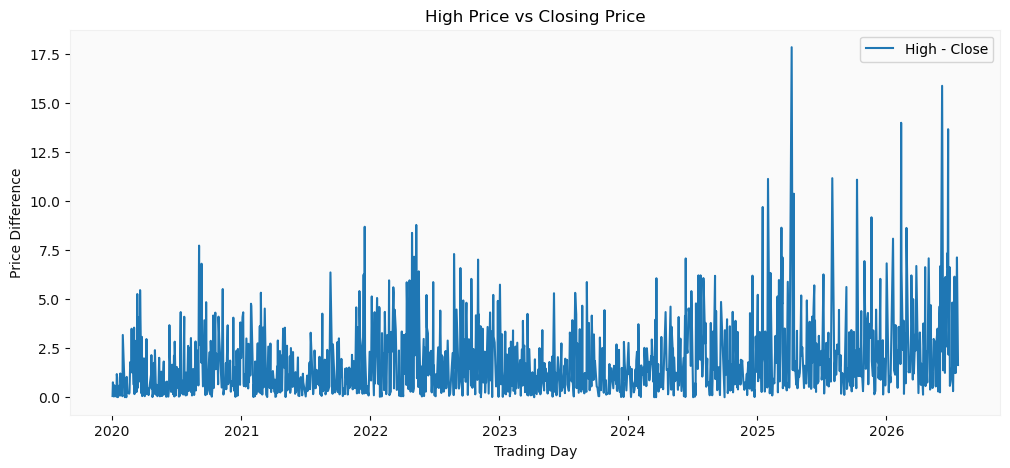

In [236]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["High_Close_Diff"],
    label="High - Close"
)

plt.title("High Price vs Closing Price")
plt.xlabel("Trading Day")
plt.ylabel("Price Difference")
plt.legend()
plt.grid()

plt.show()

In [237]:
#8 Moving average features

In [238]:
data["MA10"] = data["Close"].rolling(10).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()

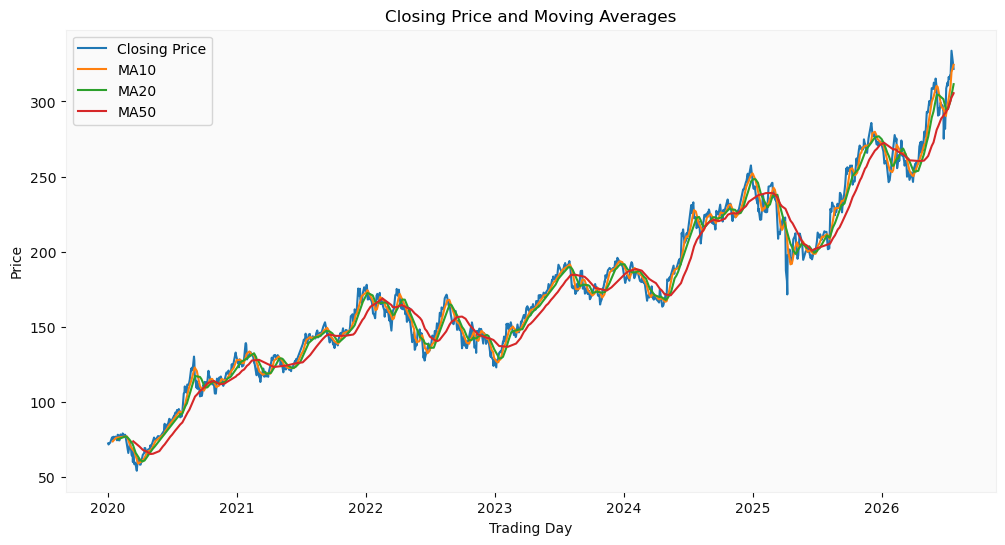

In [239]:
plt.figure(figsize=(12, 6))

plt.plot(data["Close"], label="Closing Price")
plt.plot(data["MA10"], label="MA10")
plt.plot(data["MA20"], label="MA20")
plt.plot(data["MA50"], label="MA50")

plt.title("Closing Price and Moving Averages")
plt.xlabel("Trading Day")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

In [240]:
# Moving average diference

In [241]:
data["MA10_MA20"] = (
    data["MA10"] -
    data["MA20"]
)

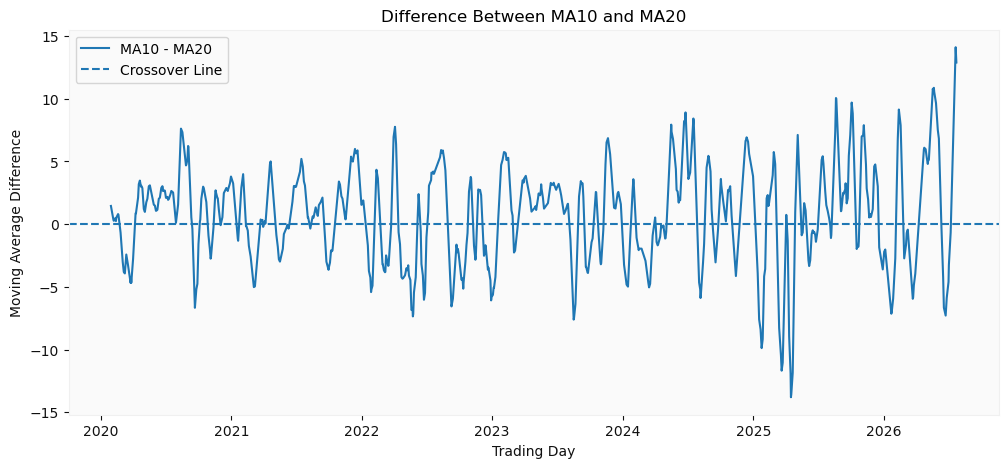

In [242]:
plt.figure(figsize=(12, 5))

plt.plot(
    data["MA10_MA20"],
    label="MA10 - MA20"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Crossover Line"
)

plt.title("Difference Between MA10 and MA20")
plt.xlabel("Trading Day")
plt.ylabel("Moving Average Difference")
plt.legend()
plt.grid()

plt.show()

## Feature Enginering

In [243]:
data.head(30)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20
Date,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,0.989823,0.060208,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,1.447395,0.038534,NaN,NaN,NaN
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,1.452217,0.301040,NaN,NaN,NaN
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN
2020-01-13,76.334076,76.360571,74.934843,75.052856,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN
2020-01-14,75.303337,76.481009,75.180518,76.271486,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN


In [244]:
data["MA50_Close"] = data["Close"].rolling(50).mean()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close
Date,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,0.989823,0.060208,NaN,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,1.447395,0.038534,NaN,NaN,NaN,NaN
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,1.452217,0.301040,NaN,NaN,NaN,NaN
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN,NaN
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN,NaN
2020-01-13,76.334076,76.360571,74.934843,75.052856,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN,NaN
2020-01-14,75.303337,76.481009,75.180518,76.271486,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN,NaN


In [245]:
data['Daily_Return'] = data['Close'].pct_change()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007969
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,1.452217,0.301040,NaN,NaN,NaN,NaN,0.016086
2020-01-09,74.568787,74.761449,73.742735,73.993195,170108400,NaN,NaN,0.287927,NaN,1.018714,0.575592,0.192663,NaN,NaN,NaN,NaN,0.021240
2020-01-10,74.737373,75.300927,74.236446,74.802403,140644800,NaN,NaN,-0.173205,NaN,1.064480,-0.065029,0.563553,NaN,NaN,NaN,NaN,0.002261
2020-01-13,76.334076,76.360571,74.934843,75.052856,121532000,NaN,NaN,-0.135894,NaN,1.425728,1.281220,0.026495,NaN,NaN,NaN,NaN,0.021364
2020-01-14,75.303337,76.481009,75.180518,76.271486,161954400,NaN,NaN,0.332607,NaN,1.300491,-0.968149,1.177672,NaN,NaN,NaN,NaN,-0.013503


## Calendar Features

In [246]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007969
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,1.452217,0.301040,NaN,NaN,NaN,NaN,0.016086


In [247]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Close            1647 non-null   float64
 1   High             1647 non-null   float64
 2   Low              1647 non-null   float64
 3   Open             1647 non-null   float64
 4   Volume           1647 non-null   int64  
 5   MA20             1628 non-null   float64
 6   Volume_MA20      1628 non-null   float64
 7   Volume_Change    1646 non-null   float64
 8   Relative_Volume  1628 non-null   float64
 9   Daily_Range      1647 non-null   float64
 10  Close_Open_Diff  1647 non-null   float64
 11  High_Close_Diff  1647 non-null   float64
 12  MA10             1638 non-null   float64
 13  MA50             1598 non-null   float64
 14  MA10_MA20        1628 non-null   float64
 15  MA50_Close       1598 non-null   float64
 16  Daily_Return     1646 non-null   float64
d

In [248]:
data.index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2026-07-10', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23'],
              dtype='datetime64[ns]', name='Date', length=1647, freq=None)

In [249]:
data["Day"] = data.index.day

In [250]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day
Date,,,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007969,6
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,1.452217,0.301040,NaN,NaN,NaN,NaN,0.016086,8


In [251]:
data["Weekday"] = data.index.weekday

In [252]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday
Date,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2,3
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007969,6,0
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,1.452217,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2


In [253]:
data["Month"]= data.index.month

In [254]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,Close_Open_Diff,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,0.989823,0.060208,NaN,NaN,NaN,NaN,NaN,2,3,1
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,0.067433,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4,1
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,1.447395,0.038534,NaN,NaN,NaN,NaN,0.007969,6,0,1
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,-0.349202,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1,1
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,1.452217,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2,1


In [255]:
data["Year"] = data.index.year

In [256]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,...,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,NaN,NaN,NaN,NaN,1.302901,...,0.060208,NaN,NaN,NaN,NaN,NaN,2,3,1,2020
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,NaN,NaN,0.080029,NaN,0.982591,...,0.758619,NaN,NaN,NaN,NaN,-0.009722,3,4,1,2020
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,NaN,NaN,-0.190918,NaN,1.736397,...,0.038534,NaN,NaN,NaN,NaN,0.007969,6,0,1,2020
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,-0.080374,NaN,0.823641,...,0.604483,NaN,NaN,NaN,NaN,-0.004703,7,1,1,2020
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,NaN,NaN,0.213160,NaN,1.753257,...,0.301040,NaN,NaN,NaN,NaN,0.016086,8,2,1,2020


In [257]:
# mean imputation
data['MA20']= data['MA20'].fillna(data['MA20'].mean())
data['MA50_Close']= data['MA50_Close'].fillna(data['MA50_Close'].mean())
data['Daily_Return']= data['Daily_Return'].fillna(data['Daily_Return'].mean())

In [258]:
data['Volume_MA20']= data['Volume_MA20'].fillna(data['Volume_MA20'].mean())
data['Volume_Change']= data['Volume_Change'].fillna(data['Volume_Change'].mean())
data['Relative_Volume']= data['Relative_Volume'].fillna(data['Relative_Volume'].mean())
data['MA10']= data['MA10'].fillna(data['MA10'].mean())
data['MA50']= data['MA50'].fillna(data['MA50'].mean())
data['MA10_MA20']= data['MA10_MA20'].fillna(data['MA10_MA20'].mean())

In [259]:
data.isnull().sum()

Price
Close              0
High               0
Low                0
Open               0
Volume             0
MA20               0
Volume_MA20        0
Volume_Change      0
Relative_Volume    0
Daily_Range        0
Close_Open_Diff    0
High_Close_Diff    0
MA10               0
MA50               0
MA10_MA20          0
MA50_Close         0
Daily_Return       0
Day                0
Weekday            0
Month              0
Year               0
dtype: int64

In [260]:
data.head()

Price,Close,High,Low,Open,Volume,MA20,Volume_MA20,Volume_Change,Relative_Volume,Daily_Range,...,High_Close_Diff,MA10,MA50,MA10_MA20,MA50_Close,Daily_Return,Day,Weekday,Month,Year
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333855,72.394063,71.091161,71.344032,135480400,173.95599,8.154419e+07,0.046637,1.000492,1.302901,...,0.060208,174.088138,173.684148,0.739015,173.684148,0.001102,2,3,1,2020
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,173.95599,8.154419e+07,0.080029,1.000492,0.982591,...,0.758619,174.088138,173.684148,0.739015,173.684148,-0.009722,3,4,1,2020
2020-01-06,72.201439,72.239973,70.503576,70.754043,118387200,173.95599,8.154419e+07,-0.190918,1.000492,1.736397,...,0.038534,174.088138,173.684148,0.739015,173.684148,0.007969,6,0,1,2020
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,173.95599,8.154419e+07,-0.080374,1.000492,0.823641,...,0.604483,174.088138,173.684148,0.739015,173.684148,-0.004703,7,1,1,2020
2020-01-08,73.017853,73.318893,71.565636,71.565636,132079200,173.95599,8.154419e+07,0.213160,1.000492,1.753257,...,0.301040,174.088138,173.684148,0.739015,173.684148,0.016086,8,2,1,2020


## Feature Selection

In [261]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'Volume_MA20',
       'Volume_Change', 'Relative_Volume', 'Daily_Range', 'Close_Open_Diff',
       'High_Close_Diff', 'MA10', 'MA50', 'MA10_MA20', 'MA50_Close',
       'Daily_Return', 'Day', 'Weekday', 'Month', 'Year'],
      dtype='object', name='Price')

In [262]:
x = data.drop(columns = ['Close'], axis = 1)


In [263]:
y = data['Close']

## Time-Series (Train, Test, Split)

In [264]:
# Normal dataset
from sklearn.model_selection import train_test_split

In [265]:
train_size = int(len(x)*0.7)
val_size = int(len(x)*0.3)

In [266]:
x_train = x.iloc[:train_size]
y_train = y.iloc[:train_size]

In [267]:
train_size

1152

In [268]:
x_test = x.iloc[train_size:]
y_test = y.iloc[train_size:]


In [269]:
print(f"x_train = {x_train.shape}")
print(f"y_train = {y_train.shape}")

x_train = (1152, 20)
y_train = (1152,)


In [270]:
print(f"x_test = {x_test.shape}")
print(f"y_test = {y_test.shape}")

x_test = (495, 20)
y_test = (495,)


## Model Training 

In [271]:
from sklearn.linear_model import LinearRegression

In [272]:
model = LinearRegression()

In [273]:
x.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1647 entries, 2020-01-02 to 2026-07-23
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   High             1647 non-null   float64
 1   Low              1647 non-null   float64
 2   Open             1647 non-null   float64
 3   Volume           1647 non-null   int64  
 4   MA20             1647 non-null   float64
 5   Volume_MA20      1647 non-null   float64
 6   Volume_Change    1647 non-null   float64
 7   Relative_Volume  1647 non-null   float64
 8   Daily_Range      1647 non-null   float64
 9   Close_Open_Diff  1647 non-null   float64
 10  High_Close_Diff  1647 non-null   float64
 11  MA10             1647 non-null   float64
 12  MA50             1647 non-null   float64
 13  MA10_MA20        1647 non-null   float64
 14  MA50_Close       1647 non-null   float64
 15  Daily_Return     1647 non-null   float64
 16  Day              1647 non-null   int32  
 

In [274]:
x.isna().sum()

Price
High               0
Low                0
Open               0
Volume             0
MA20               0
Volume_MA20        0
Volume_Change      0
Relative_Volume    0
Daily_Range        0
Close_Open_Diff    0
High_Close_Diff    0
MA10               0
MA50               0
MA10_MA20          0
MA50_Close         0
Daily_Return       0
Day                0
Weekday            0
Month              0
Year               0
dtype: int64

In [275]:
x_train.isnull().sum()

Price
High               0
Low                0
Open               0
Volume             0
MA20               0
Volume_MA20        0
Volume_Change      0
Relative_Volume    0
Daily_Range        0
Close_Open_Diff    0
High_Close_Diff    0
MA10               0
MA50               0
MA10_MA20          0
MA50_Close         0
Daily_Return       0
Day                0
Weekday            0
Month              0
Year               0
dtype: int64

In [276]:
model.fit(x_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [277]:
predictions = model.predict(x_test)

In [278]:
predictions

array([216.4847107 , 217.97183228, 207.47277833, 205.45028687,
       208.01808167, 211.47805787, 214.38293457, 215.91145325,
       219.62364197, 220.07029724, 223.04797363, 224.36808777,
       224.20925904, 224.82461548, 224.7154541 , 222.85939026,
       225.15219117, 225.48963929, 226.33332825, 224.80480957,
       228.08026123, 227.29612732, 221.11247254, 219.20677185,
       220.72538758, 219.17701722, 219.26631165, 218.47225952,
       221.0032959 , 221.11247254, 220.84446716, 214.71047974,
       215.17697144, 219.04795838, 227.167099  , 226.50205992,
       224.78495789, 225.67825318, 224.68568421, 225.82714844,
       226.09512329, 231.26635742, 224.52687073, 225.09263611,
       223.99090577, 225.11250306, 220.04052735, 224.09017945,
       227.83212281, 227.33584595, 225.8569336 , 229.57902527,
       232.11004639, 230.05543518, 230.42266846, 233.2514801 ,
       234.72045899, 234.10507202, 229.04299927, 228.85444641,
       229.68820191, 231.66339111, 231.93138123, 228.38

In [279]:
data_pred = pd.DataFrame(y_test)
data_pred['Predictions Value'] = predictions
#data_pred['Actual Value'] = y_test


In [280]:
data_pred

,Close,Predictions Value
Date,,
2024-08-01,216.484711,216.484711
2024-08-02,217.971832,217.971832
2024-08-05,207.472778,207.472778
2024-08-06,205.450287,205.450287
2024-08-07,208.018082,208.018082
...,...,...
2026-07-17,333.739990,333.739990
2026-07-20,326.589996,326.589996
2026-07-21,327.739990,327.739990


## Model Evaluation

In [281]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [282]:
#Calculate mse
mse = mean_squared_error(y_test, predictions)

In [283]:
print(f"MSE:{mse:.4f}")
print(f"MSE:{mse}")

MSE:0.0000
MSE:2.1064914289119822e-17


In [284]:
rmse = root_mean_squared_error(y_test, predictions)
print(f"RMSE:{rmse:.4f}")

RMSE:0.0000


## Saving ML Model

In [285]:
import joblib

In [286]:
joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

### Loading the saved model

In [287]:
saved_model = joblib.load('linear_regression_model.pkl')

In [288]:
saved_predictions = saved_model.predict(x_test)

In [289]:
saved_predictions

array([216.4847107 , 217.97183228, 207.47277833, 205.45028687,
       208.01808167, 211.47805787, 214.38293457, 215.91145325,
       219.62364197, 220.07029724, 223.04797363, 224.36808777,
       224.20925904, 224.82461548, 224.7154541 , 222.85939026,
       225.15219117, 225.48963929, 226.33332825, 224.80480957,
       228.08026123, 227.29612732, 221.11247254, 219.20677185,
       220.72538758, 219.17701722, 219.26631165, 218.47225952,
       221.0032959 , 221.11247254, 220.84446716, 214.71047974,
       215.17697144, 219.04795838, 227.167099  , 226.50205992,
       224.78495789, 225.67825318, 224.68568421, 225.82714844,
       226.09512329, 231.26635742, 224.52687073, 225.09263611,
       223.99090577, 225.11250306, 220.04052735, 224.09017945,
       227.83212281, 227.33584595, 225.8569336 , 229.57902527,
       232.11004639, 230.05543518, 230.42266846, 233.2514801 ,
       234.72045899, 234.10507202, 229.04299927, 228.85444641,
       229.68820191, 231.66339111, 231.93138123, 228.38

In [290]:
mse = mean_squared_error(y_test, saved_predictions)

In [291]:
mse

2.1064914289119822e-17